# Household Electricity Consumption Analysis

**Portfolio project:** time-series analysis, missing-data handling,
feature engineering, exploratory analysis, anomaly detection, and
dashboard-ready aggregation.

This notebook analyzes the supplied subset of the UCI Individual
Household Electric Power Consumption dataset.

## Executive summary

- **Observations:** 1,048,575 minute-level rows
- **Period:** 16 December 2006 – 13 December 2008
- **Average complete-day energy:** 26.6 kWh
- **Peak average hour:** 21:00
- **Weekend uplift:** 22.4%
- **High-usage anomalies:** 16 days
- **Missing rows in raw data:** 4,069

The cleaning strategy interpolates only short gaps and preserves longer
missing periods through a coverage metric.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/raw/household_power_consumption.csv")
PROCESSED_DIR = Path("../data/processed")
pd.set_option("display.max_columns", None)

## 1. Load and audit the data

In [2]:
df = pd.read_csv(DATA_PATH, na_values="?", low_memory=False)
print(f"Shape: {df.shape}")
df.head()

Shape: (1048575, 9)


The file contains **1,048,575 rows** and
nine original variables. Missing measurements are represented by `?`
in the CSV and become `NaN` during import.

## 2. Data cleaning

In [3]:
numeric_columns = [
    "Global_active_power", "Global_reactive_power", "Voltage",
    "Global_intensity", "Sub_metering_1", "Sub_metering_2",
    "Sub_metering_3"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

df = (
    df.drop(columns=["Date", "Time"])
      .dropna(subset=["datetime"])
      .drop_duplicates(subset=["datetime"])
      .set_index("datetime")
      .sort_index()
)

missing = df["Global_active_power"].isna()
missing_group = missing.ne(missing.shift()).cumsum()
run_size = missing.groupby(missing_group).transform("sum")
short_gap = missing & (run_size <= 60)

interpolated = df[numeric_columns].interpolate(
    method="time", limit_direction="both"
)
df.loc[short_gap, numeric_columns] = interpolated.loc[
    short_gap, numeric_columns
]

print("Raw missing rows:", int(missing.sum()))
print("Short-gap rows imputed:", int(short_gap.sum()))
print("Rows retained as missing:", int(df["Global_active_power"].isna().sum()))

Raw missing rows: 4069
Short-gap rows imputed: 193
Rows retained as missing: 3876


Long gaps are deliberately left missing. Linear
interpolation across multi-hour or multi-day outages could create
misleading synthetic consumption patterns.

## 3. Feature engineering and aggregation

In [4]:
df["energy_kwh"] = df["Global_active_power"] / 60

for meter in (1, 2, 3):
    df[f"sub_metering_{meter}_kwh"] = (
        df[f"Sub_metering_{meter}"] / 1000
    )

df["other_energy_kwh"] = (
    df["energy_kwh"]
    - df["sub_metering_1_kwh"]
    - df["sub_metering_2_kwh"]
    - df["sub_metering_3_kwh"]
).clip(lower=0)

daily = pd.read_csv(
    PROCESSED_DIR / "electricity_daily.csv",
    parse_dates=["datetime"]
)
hourly = pd.read_csv(
    PROCESSED_DIR / "electricity_hourly.csv",
    parse_dates=["datetime"]
)

daily.head()

`Global_active_power` is minute-averaged power in kW, so
dividing it by 60 converts each one-minute observation into kWh.
The three sub-meter readings are originally watt-hours per minute and
are divided by 1,000.

## 4. Daily consumption trend

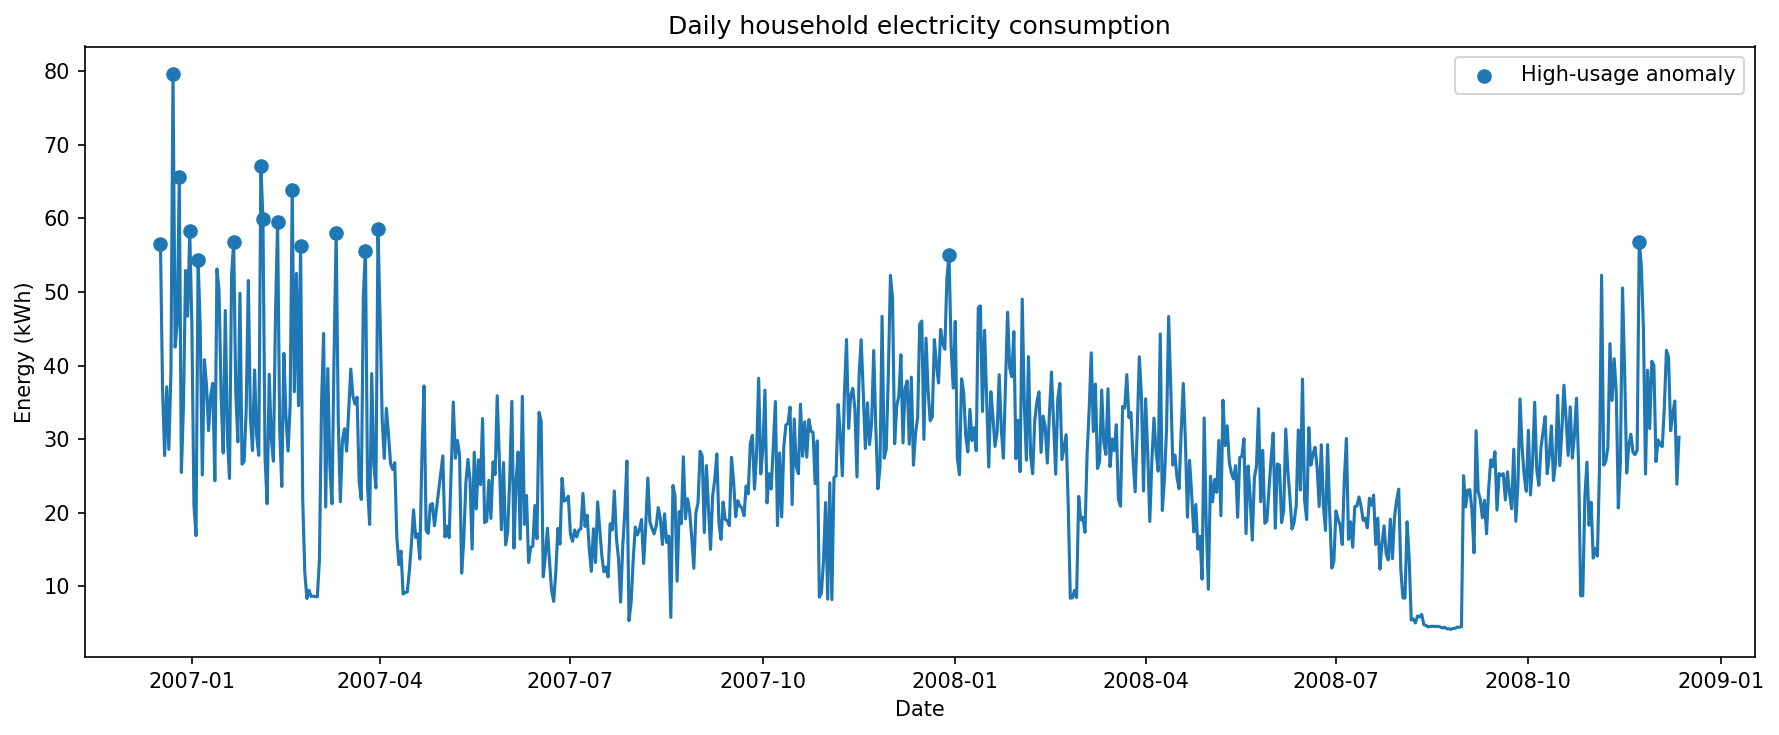

In [5]:
complete_daily = daily[daily["coverage_pct"] >= 95].copy()
high_usage = complete_daily[
    complete_daily["anomaly_status"] == "High usage"
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(complete_daily["datetime"], complete_daily["energy_kwh"])
ax.scatter(
    high_usage["datetime"], high_usage["energy_kwh"],
    label="High-usage anomaly"
)
ax.set(
    title="Daily household electricity consumption",
    xlabel="Date", ylabel="Energy (kWh)"
)
ax.legend()
plt.show()

The highest complete-day consumption was
**79.6 kWh** on
**2006-12-23**. The 1.5×IQR rule identified
**16 high-usage days**.

## 5. Intraday load profile

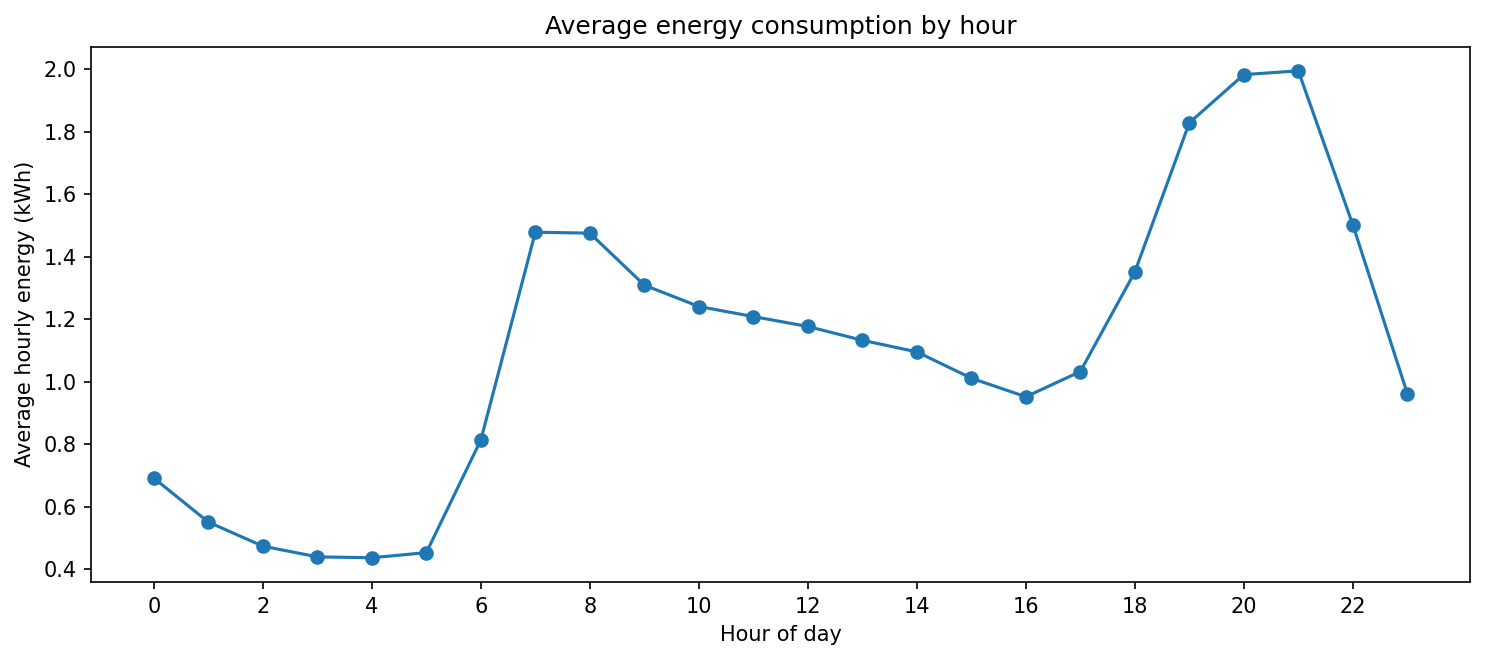

In [6]:
complete_hourly = hourly[hourly["coverage_pct"] >= 95]
hourly_profile = (
    complete_hourly.groupby("hour")["energy_kwh"].mean()
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(hourly_profile.index, hourly_profile.values, marker="o")
ax.set(
    title="Average energy consumption by hour",
    xlabel="Hour of day", ylabel="Average energy (kWh)"
)
plt.show()

The typical load is lowest around
**04:00** and peaks around
**21:00**, indicating a pronounced evening
demand pattern.

## 6. Weekday and weekend consumption

In [7]:
day_type_summary = (
    complete_daily.groupby("day_type")["energy_kwh"]
    .agg(["mean", "median", "count"])
)
day_type_summary

Weekend usage averaged
**30.6 kWh/day**, compared with
**25.0 kWh/day** on weekdays.
That is a **22.4% increase**.

## 7. Day–hour heatmap

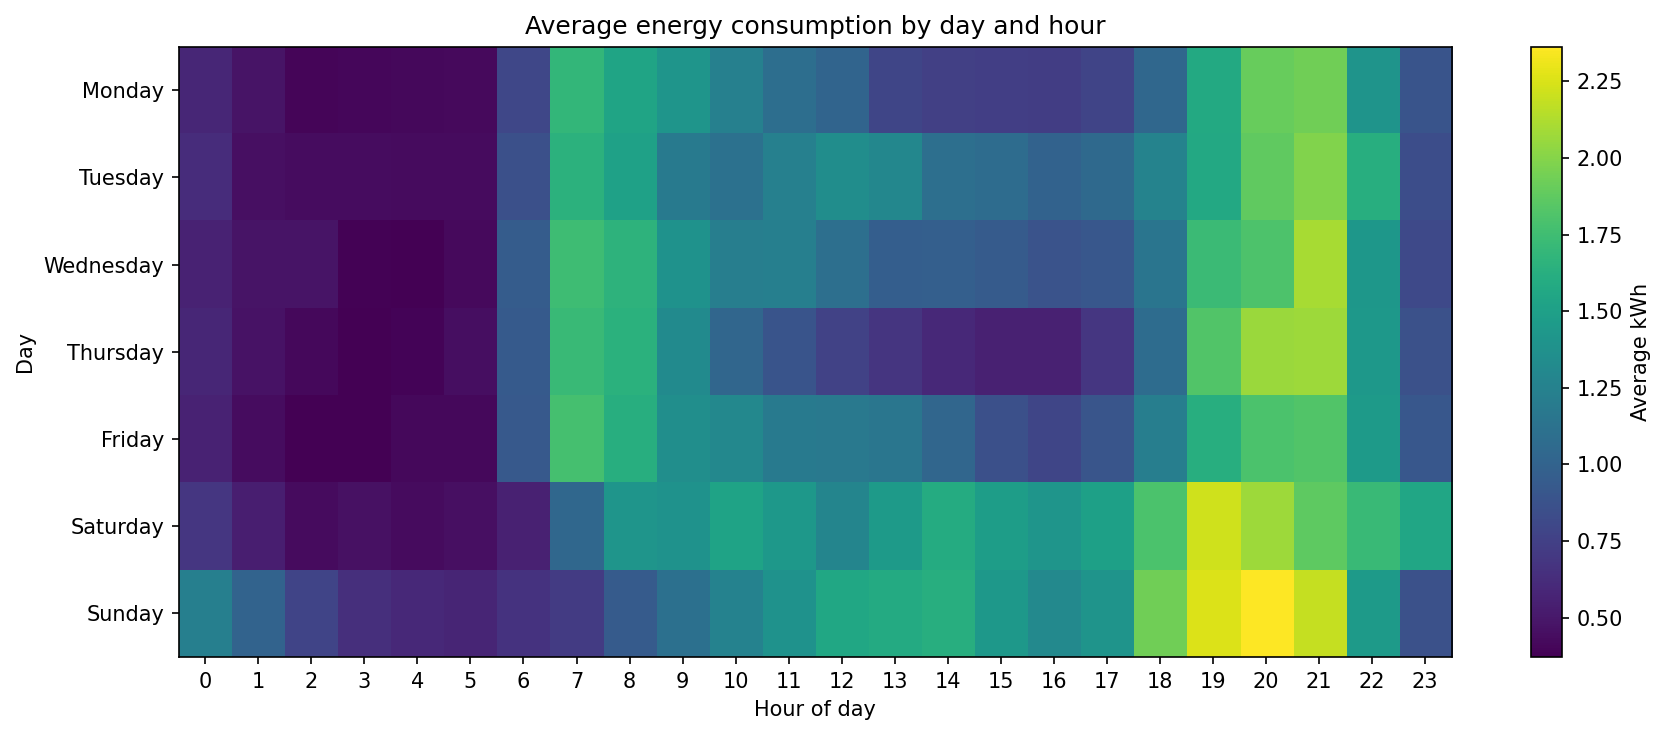

In [8]:
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]
heatmap = (
    complete_hourly.pivot_table(
        index="day_name", columns="hour",
        values="energy_kwh", aggfunc="mean"
    )
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(12, 5))
image = ax.imshow(heatmap.values, aspect="auto")
ax.set(
    title="Average energy consumption by day and hour",
    xlabel="Hour of day", ylabel="Day"
)
ax.set_xticks(range(24))
ax.set_yticks(range(7), day_order)
fig.colorbar(image, ax=ax, label="Average kWh")
plt.show()

## 8. Energy components

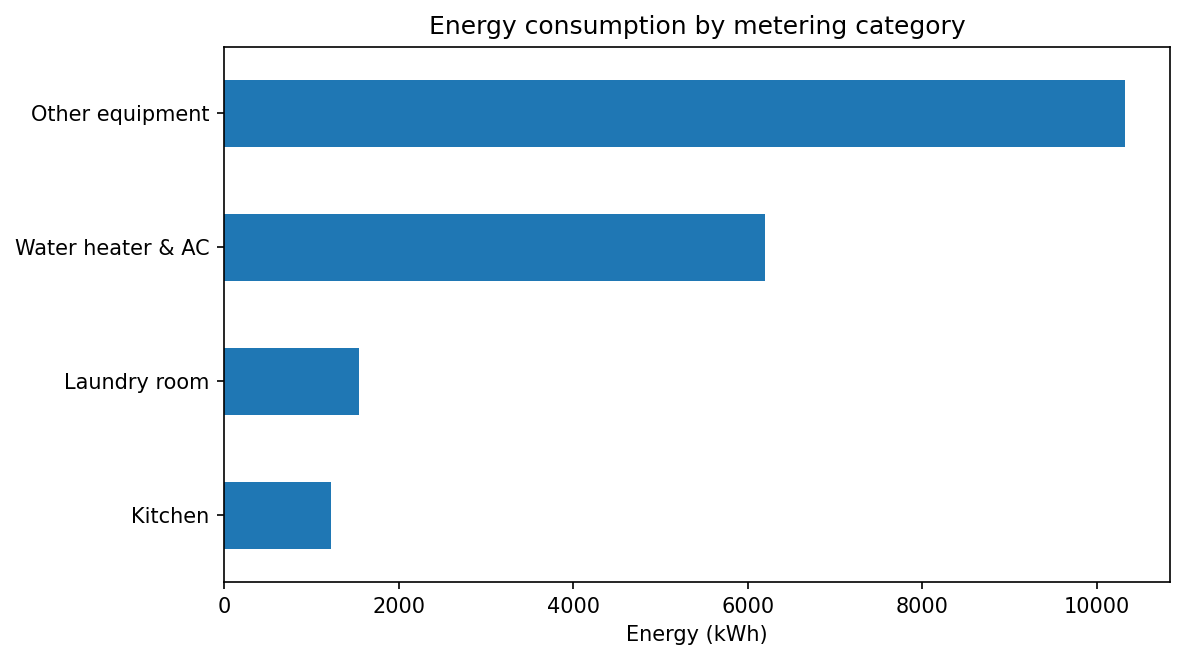

In [9]:
components = pd.Series({
    "Kitchen": daily["sub_metering_1_kwh"].sum(),
    "Laundry room": daily["sub_metering_2_kwh"].sum(),
    "Water heater & AC": daily["sub_metering_3_kwh"].sum(),
    "Other equipment": daily["other_energy_kwh"].sum()
})

components.sort_values().plot(
    kind="barh", figsize=(8, 4.5),
    title="Energy consumption by metering category"
)
plt.xlabel("Energy (kWh)")
plt.show()

The residual **other equipment** category contributed
**53.5%** of energy,
while the water-heater and air-conditioner sub-meter contributed
**32.1%**.

## 9. Conclusions and limitations

### Conclusions

1. The household displays a clear evening peak, with the highest
   average hourly use around 21:00.
2. Weekend consumption is materially higher than weekday consumption.
3. Water heating/air conditioning and unmetered equipment dominate the
   observed energy mix.
4. A small number of days show unusually high consumption under the
   IQR definition.
5. Coverage-aware aggregation prevents long missing intervals from
   being silently treated as real zero consumption.

### Limitations

- The observations come from one household.
- The supplied CSV covers only a subset of the full UCI period.
- Statistical anomalies do not identify causal faults or waste.
- Cost estimates depend on a user-provided tariff.